# IY022: Global Normalisation in Contrastive Learning

In [1]:
import torch
import torch.optim as optim
from pathlib import Path
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

from dataloaders.simclr import ssl_data_prep
from dataloaders import  save_loader_to_disk
from models.ssl_transformer import SSL_Transformer
from training.train import train_ssl_model
from info_nce import InfoNCE
import wandb
%load_ext autoreload
%autoreload 2  

In [2]:
# Setup Configuration
DATA_ROOT = Path("/home/ianyang/stochastic_simulations/experiments/EXP-26-IY020/data")
RESULTS_PATH = DATA_ROOT / "IY020_simulation_parameters_sobol.csv" #  this csv file stores all the simulation parameters used
df_params = pd.read_csv(RESULTS_PATH) 
# filter out only successful simulations with no error_message, and mean_rel_error_pct < 10, cv_rel_error_pct  < 10, & t_ac_rel_error_pct < 10
df_params = df_params[(df_params['success'] == True) & 
                    (df_params['error_message'].isna()) &
                    (df_params['mean_rel_error_pct'] < 10) & 
                    (df_params['cv_rel_error_pct'] < 10) & 
                    (df_params['t_ac_rel_error_pct'] < 10)]
TRAJ_PATH = [DATA_ROOT / df_params['trajectory_filename'].values[i] for i in range(len(df_params))]
TRAJ_NPZ_PATH = [traj_file.with_suffix('.npz') for traj_file in TRAJ_PATH]
print(f"Number of VALID trajectories: {len(TRAJ_PATH)}")

Number of VALID trajectories: 7709


```
normalisation: 'instance'
```

In [3]:
# === Dataloader hyperparams & data prep ===
batch_size = 64
num_traj=1 # number of trajectories per view
sample_len=None
log_scale = False 
normalisation = 'instance'

train_loader, val_loader, test_loader = ssl_data_prep(
    # TRAJ_NPZ_PATH,
    TRAJ_PATH,
    batch_size=batch_size,
    sample_len=sample_len,
    log_scale=log_scale,
    normalisation=normalisation,
    num_traj=num_traj,
)
# === Dataloader hyperparams & data prep ===
X1_b, X2_b, y_b = next(iter(train_loader))
print(X1_b.shape, X2_b.shape, y_b.shape) # (B, T, 1) (B, T, 1) (B, 1)

torch.Size([64, 3000, 1]) torch.Size([64, 3000, 1]) torch.Size([64, 1])


--- Train Loader (SSL Pairs) ---
Shapes :: X1: torch.Size([64, 3000, 1]), X2: torch.Size([64, 3000, 1]), y: torch.Size([64, 1])


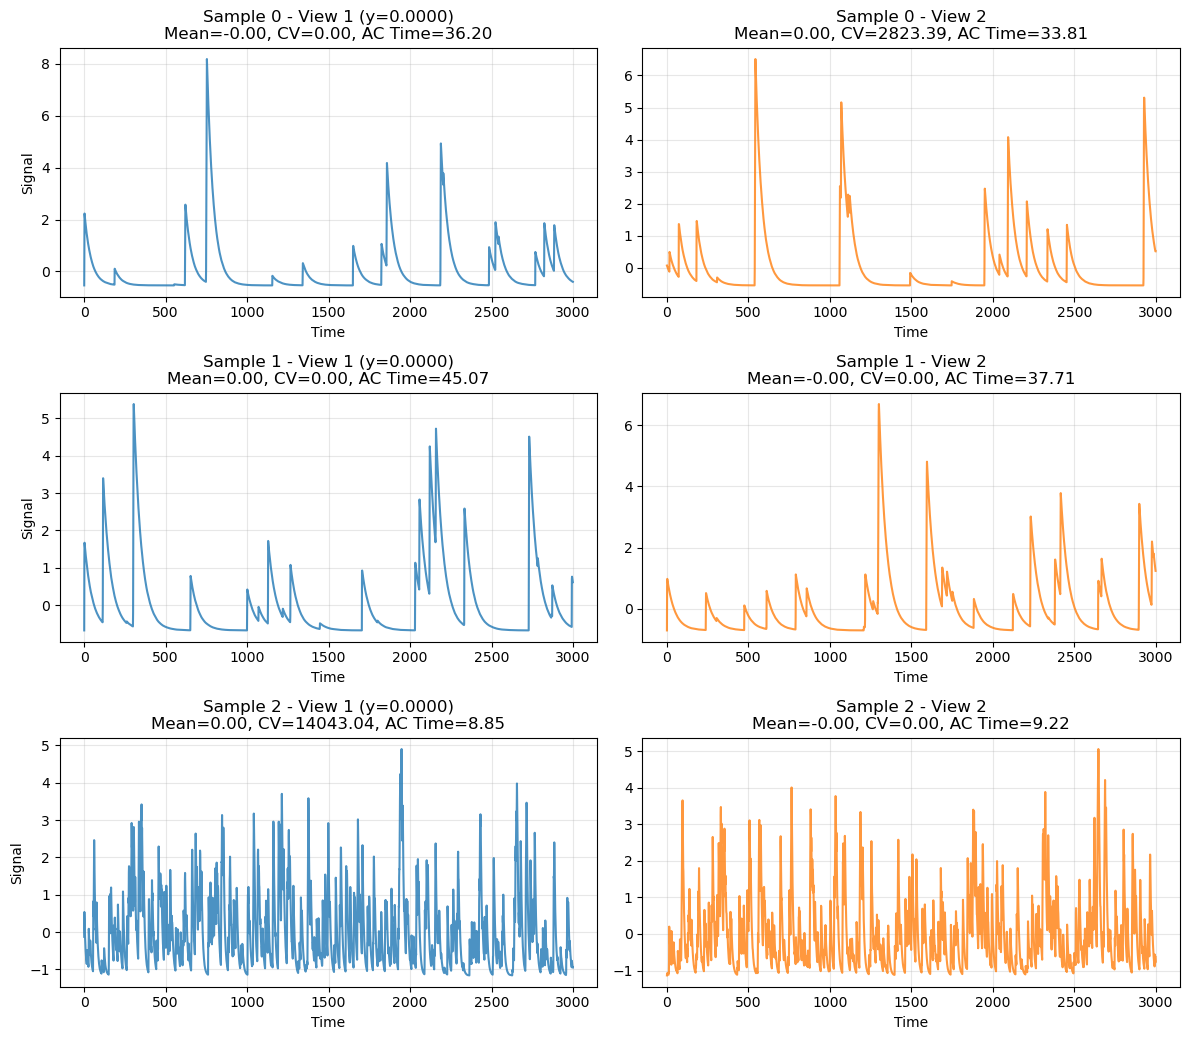

--- Validation Loader (SSL Pairs) ---
Shapes :: X1: torch.Size([64, 3000, 1]), X2: torch.Size([64, 3000, 1]), y: torch.Size([64, 1])


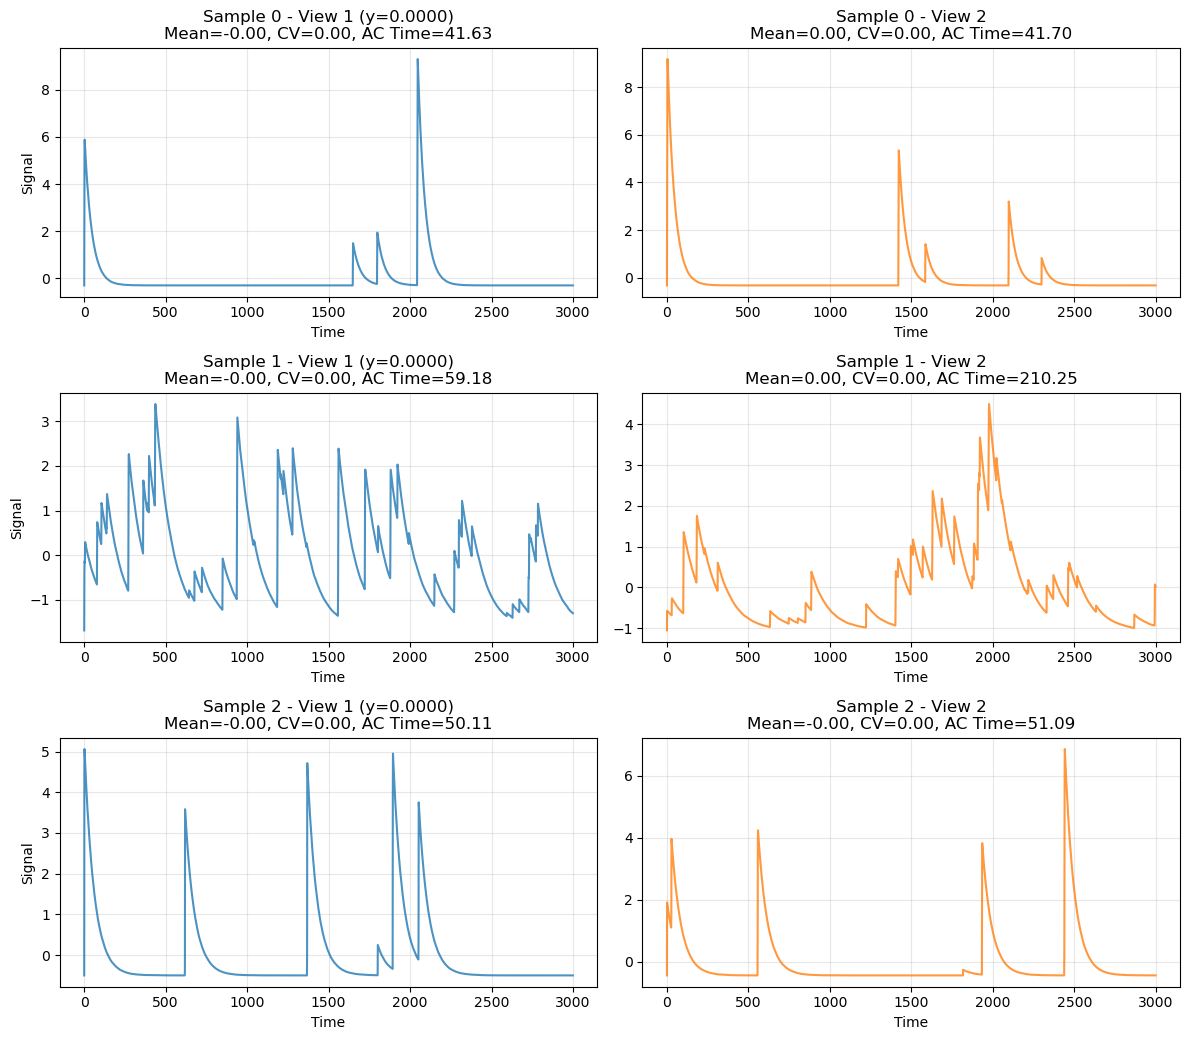

--- Test Loader (SSL Pairs) ---
Shapes :: X1: torch.Size([64, 3000, 1]), X2: torch.Size([64, 3000, 1]), y: torch.Size([64, 1])


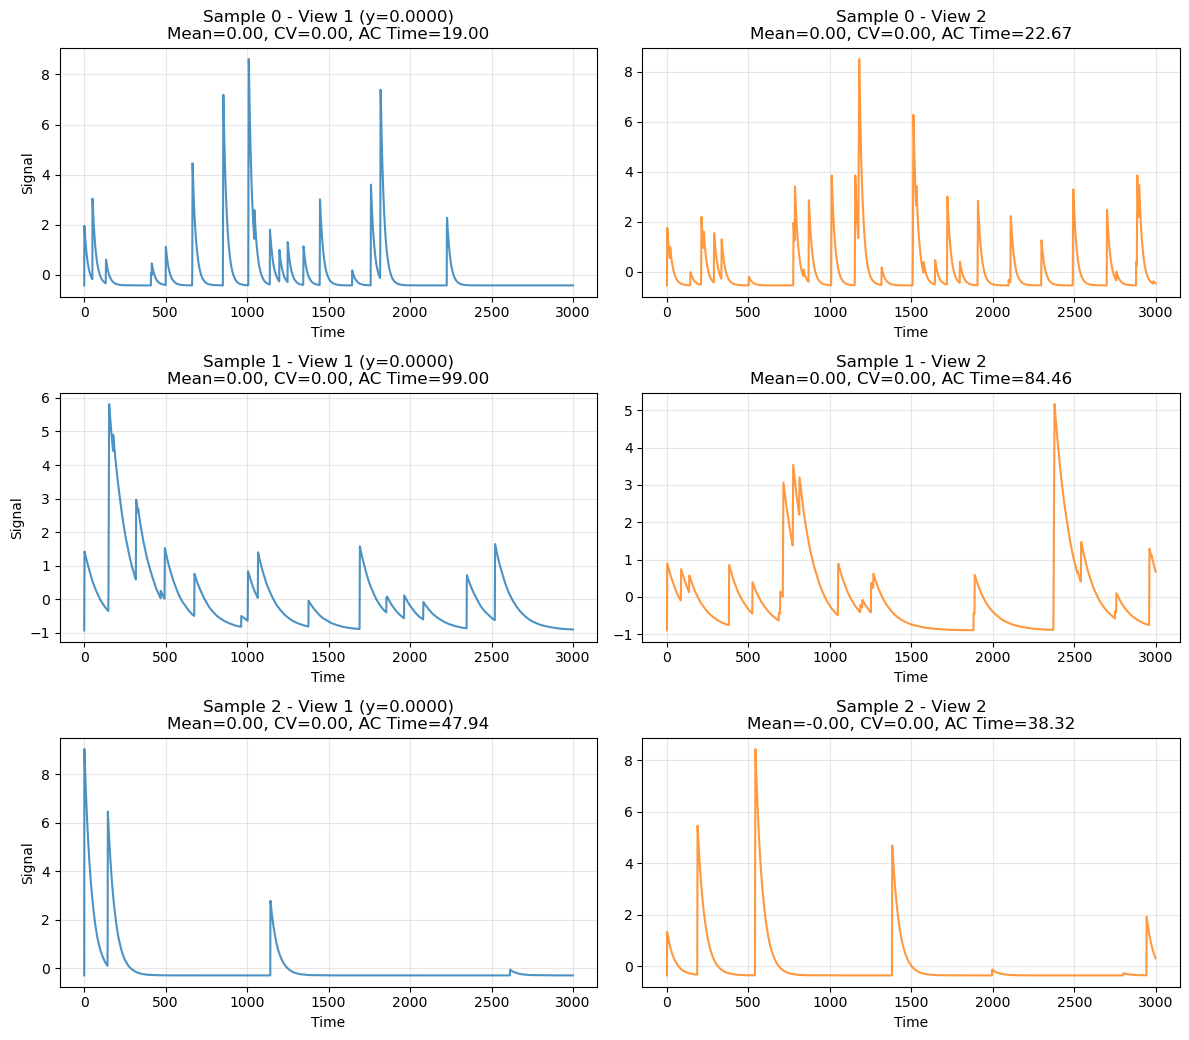

In [4]:
from stats.autocorrelation import calculate_autocorrelation, calculate_ac_time_interp1d

def visualize_loader_samples(loader, loader_name, num_samples=3):
    """
    Visualizes samples from the dataloader including Mean and CV statistics.
    Assumes loader returns (X1, X2, y) for SSL or (X, y) for standard tasks.
    """
    if not loader:
        print(f"{loader_name} is None or empty.")
        return
        
    iterator = iter(loader)
    try:
        batch = next(iterator)
    except StopIteration:
        print(f"Could not fetch batch from {loader_name}")
        return

    # Check batch structure
    if len(batch) == 3:
        X1, X2, y = batch
        has_two_views = True
        print(f"--- {loader_name} (SSL Pairs) ---")
        print(f"Shapes :: X1: {X1.shape}, X2: {X2.shape}, y: {y.shape}")
    elif len(batch) == 2:
        X1, y = batch
        X2 = None
        has_two_views = False
        print(f"--- {loader_name} (Standard) ---")
        print(f"Shapes :: X: {X1.shape}, y: {y.shape}")
    else:
        print(f"Unexpected batch format length: {len(batch)}")
        return

    # Plotting
    cols = 2 if has_two_views else 1
    fig, axes = plt.subplots(num_samples, cols, figsize=(12, 3.5 * num_samples), squeeze=False)
    
    for i in range(min(num_samples, len(X1))):
        label_str = f"{y[i].item():.4f}" if y[i].numel() == 1 else "Vector"
        
        # Stats for View 1
        x1_data = X1[i].flatten().cpu().numpy()
        mu1, std1 = np.mean(x1_data), np.std(x1_data)
        cv1 = std1 / mu1 if abs(mu1) > 1e-5 else 0
        autocorr_results1 = calculate_autocorrelation(x1_data)
        ac_mean1 = autocorr_results1["stress_ac"].mean(axis=0)
        lags1 = autocorr_results1["stress_lags"]
        ac_time_observed1 = calculate_ac_time_interp1d(ac_mean1, lags1)

        # Plot View 1
        ax1 = axes[i, 0]
        ax1.plot(x1_data, color='tab:blue', alpha=0.8)
        ax1.set_title(f"Sample {i} - View 1 (y={label_str})\nMean={mu1:.2f}, CV={cv1:.2f}, AC Time={ac_time_observed1:.2f}")
        ax1.set_xlabel("Time")
        ax1.set_ylabel("Signal")
        ax1.grid(True, alpha=0.3)
        
        # Plot View 2 if exists
        if has_two_views:
            x2_data = X2[i].flatten().cpu().numpy()
            mu2, std2 = np.mean(x2_data), np.std(x2_data)
            cv2 = std2 / mu2 if abs(mu2) > 1e-5 else 0
            autocorr_results2 = calculate_autocorrelation(x2_data)
            ac_mean2 = autocorr_results2["stress_ac"].mean(axis=0)
            lags2 = autocorr_results2["stress_lags"]
            ac_time_observed2 = calculate_ac_time_interp1d(ac_mean2, lags2)

            ax2 = axes[i, 1]
            ax2.plot(x2_data, color='tab:orange', alpha=0.8)
            ax2.set_title(f"Sample {i} - View 2\nMean={mu2:.2f}, CV={cv2:.2f}, AC Time={ac_time_observed2:.2f}")
            ax2.set_xlabel("Time")
            ax2.grid(True, alpha=0.3)
            
    plt.tight_layout()
    plt.show()

# Visualize samples
visualize_loader_samples(train_loader, "Train Loader")
if 'val_loader' in locals(): visualize_loader_samples(val_loader, "Validation Loader")
if 'test_loader' in locals(): visualize_loader_samples(test_loader, "Test Loader")

```
normalisation: 'global'
```

In [ ]:
# === Dataloader hyperparams & data prep ===
batch_size = 64
num_traj=1 # number of trajectories per view
sample_len=None
log_scale = False 
normalisation = 'global'

train_loader, val_loader, test_loader = ssl_data_prep(
    # TRAJ_NPZ_PATH,
    TRAJ_PATH,
    batch_size=batch_size,
    sample_len=sample_len,
    log_scale=log_scale,
    normalisation=normalisation,
    num_traj=num_traj,
)
# === Dataloader hyperparams & data prep ===
X1_b, X2_b, y_b = next(iter(train_loader))
print(X1_b.shape, X2_b.shape, y_b.shape) # (B, T, 1) (B, T, 1) (B, 1)

--- Train Loader (SSL Pairs) ---
Shapes :: X1: torch.Size([64, 1811, 1]), X2: torch.Size([64, 1811, 1]), y: torch.Size([64, 1])


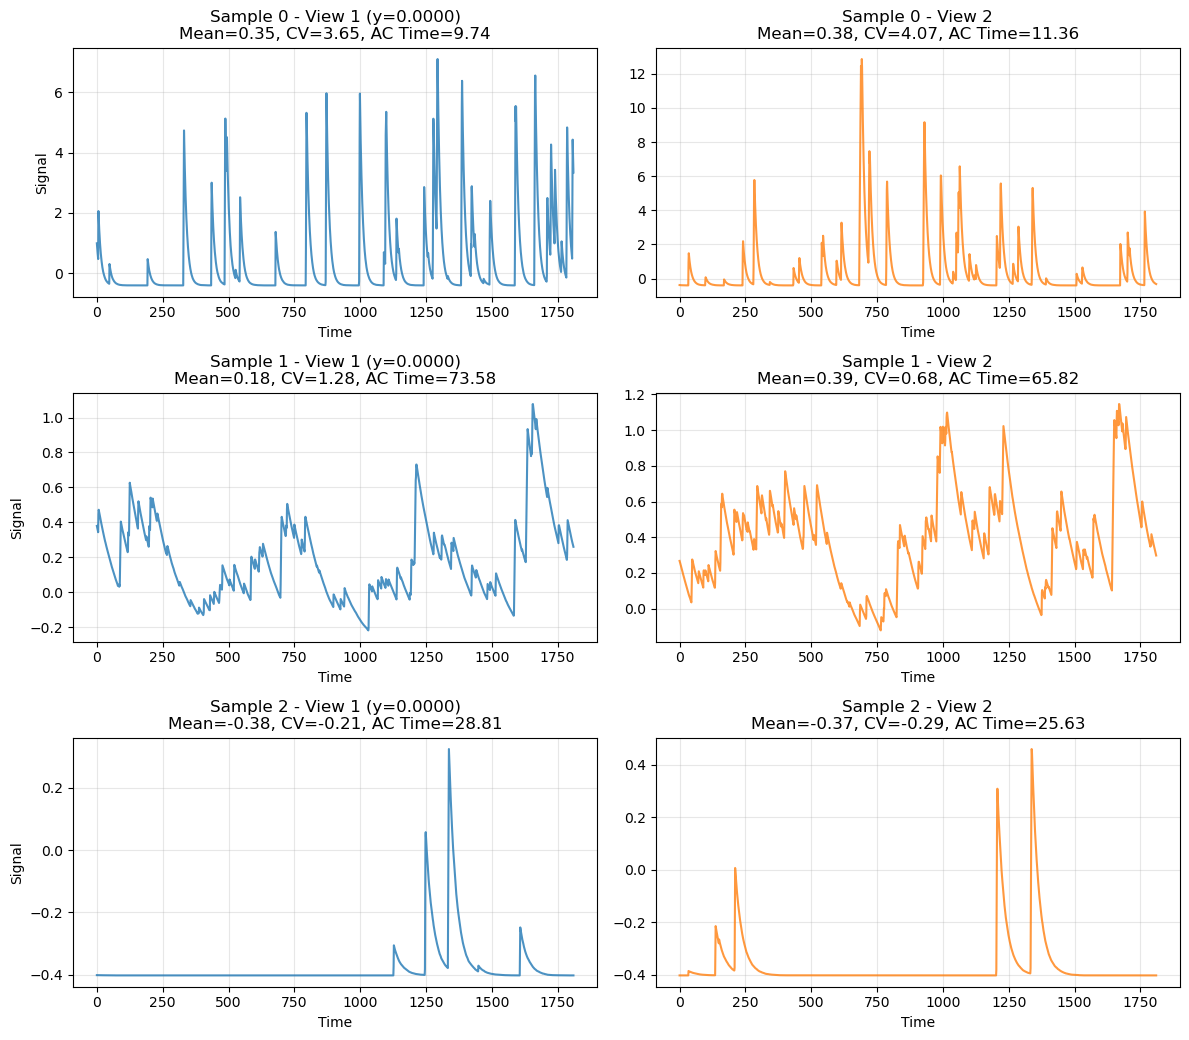

--- Validation Loader (SSL Pairs) ---
Shapes :: X1: torch.Size([64, 1811, 1]), X2: torch.Size([64, 1811, 1]), y: torch.Size([64, 1])


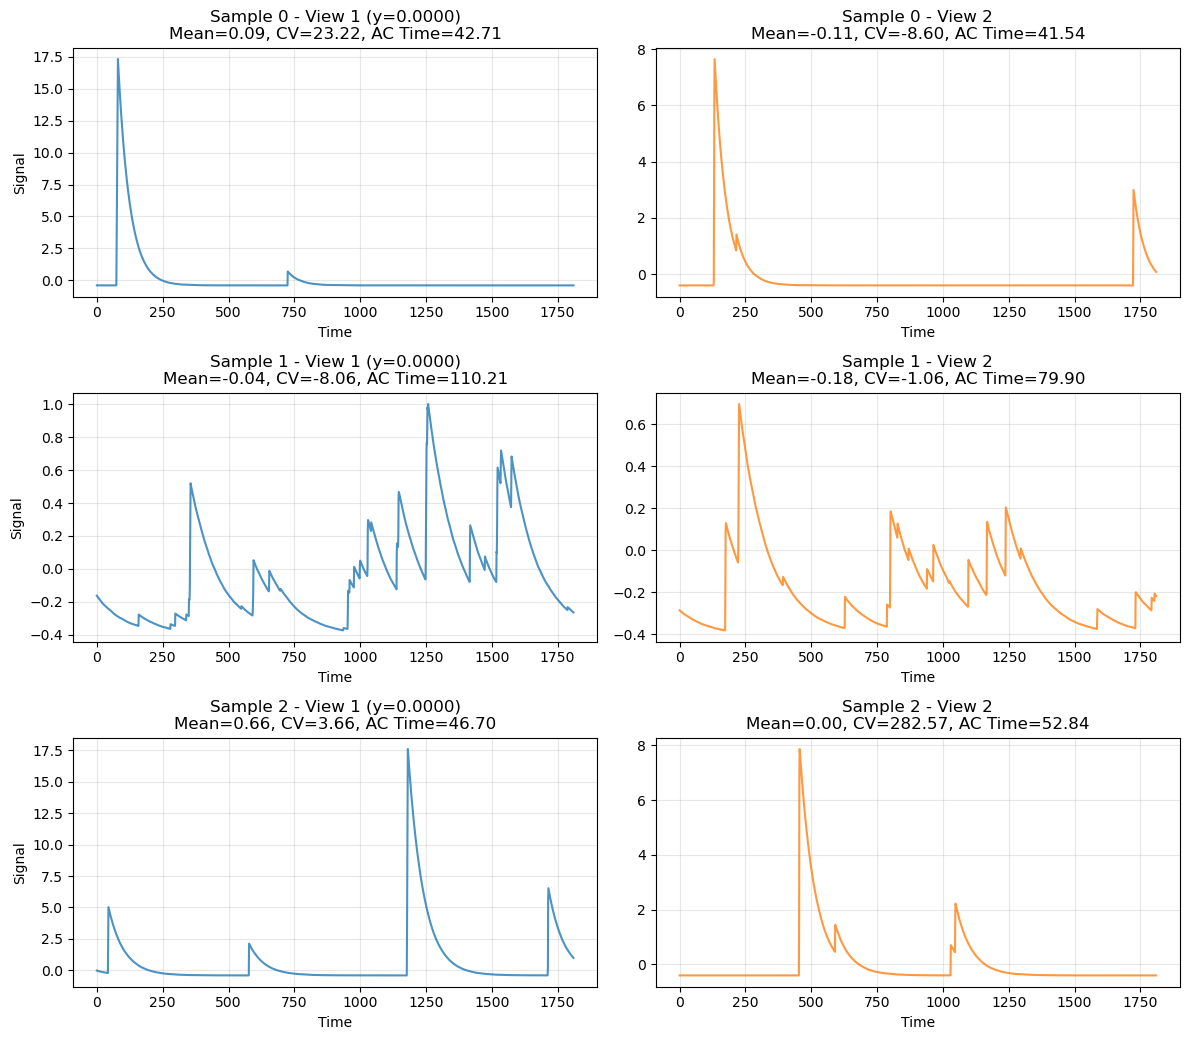

--- Test Loader (SSL Pairs) ---
Shapes :: X1: torch.Size([64, 1811, 1]), X2: torch.Size([64, 1811, 1]), y: torch.Size([64, 1])


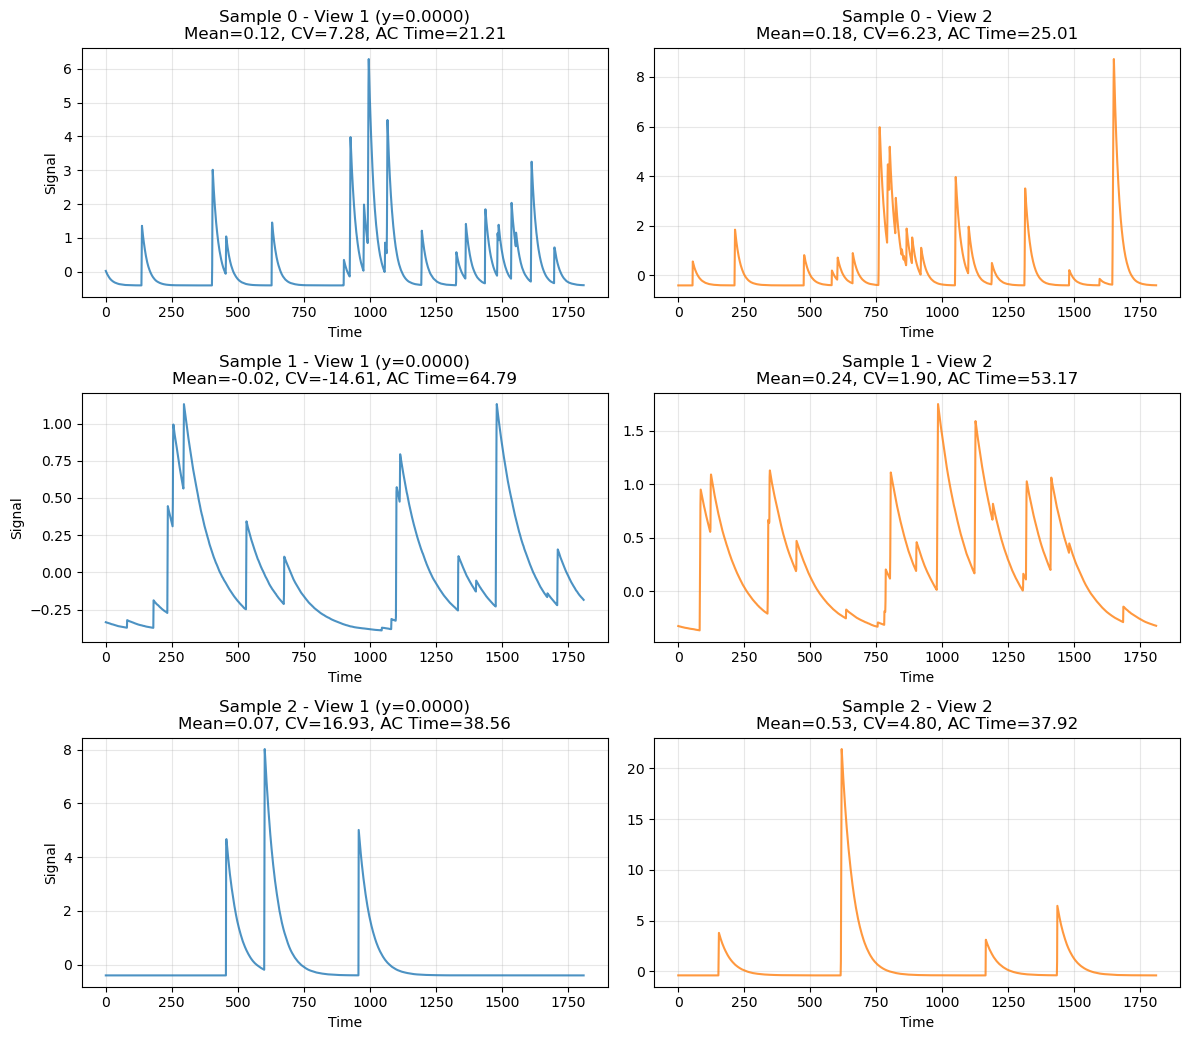

In [ ]:
# Visualize samples
visualize_loader_samples(train_loader, "Train Loader")
if 'val_loader' in locals(): visualize_loader_samples(val_loader, "Validation Loader")
if 'test_loader' in locals(): visualize_loader_samples(test_loader, "Test Loader")

```
normalisation: 'joint'
```

In [3]:
# === Dataloader hyperparams & data prep ===
batch_size = 64
num_traj=1 # number of trajectories per view
sample_len=None
log_scale = False 
normalisation = 'joint'

train_loader, val_loader, test_loader = ssl_data_prep(
    # TRAJ_NPZ_PATH,
    TRAJ_PATH,
    batch_size=batch_size,
    sample_len=sample_len,
    log_scale=log_scale,
    normalisation=normalisation,
    num_traj=num_traj,
)
# === Dataloader hyperparams & data prep ===
X1_b, X2_b, y_b = next(iter(train_loader))
print(X1_b.shape, X2_b.shape, y_b.shape) # (B, T, 1) (B, T, 1) (B, 1)

torch.Size([64, 3000, 1]) torch.Size([64, 3000, 1]) torch.Size([64, 1])


--- Train Loader (SSL Pairs) ---
Shapes :: X1: torch.Size([64, 3000, 1]), X2: torch.Size([64, 3000, 1]), y: torch.Size([64, 1])


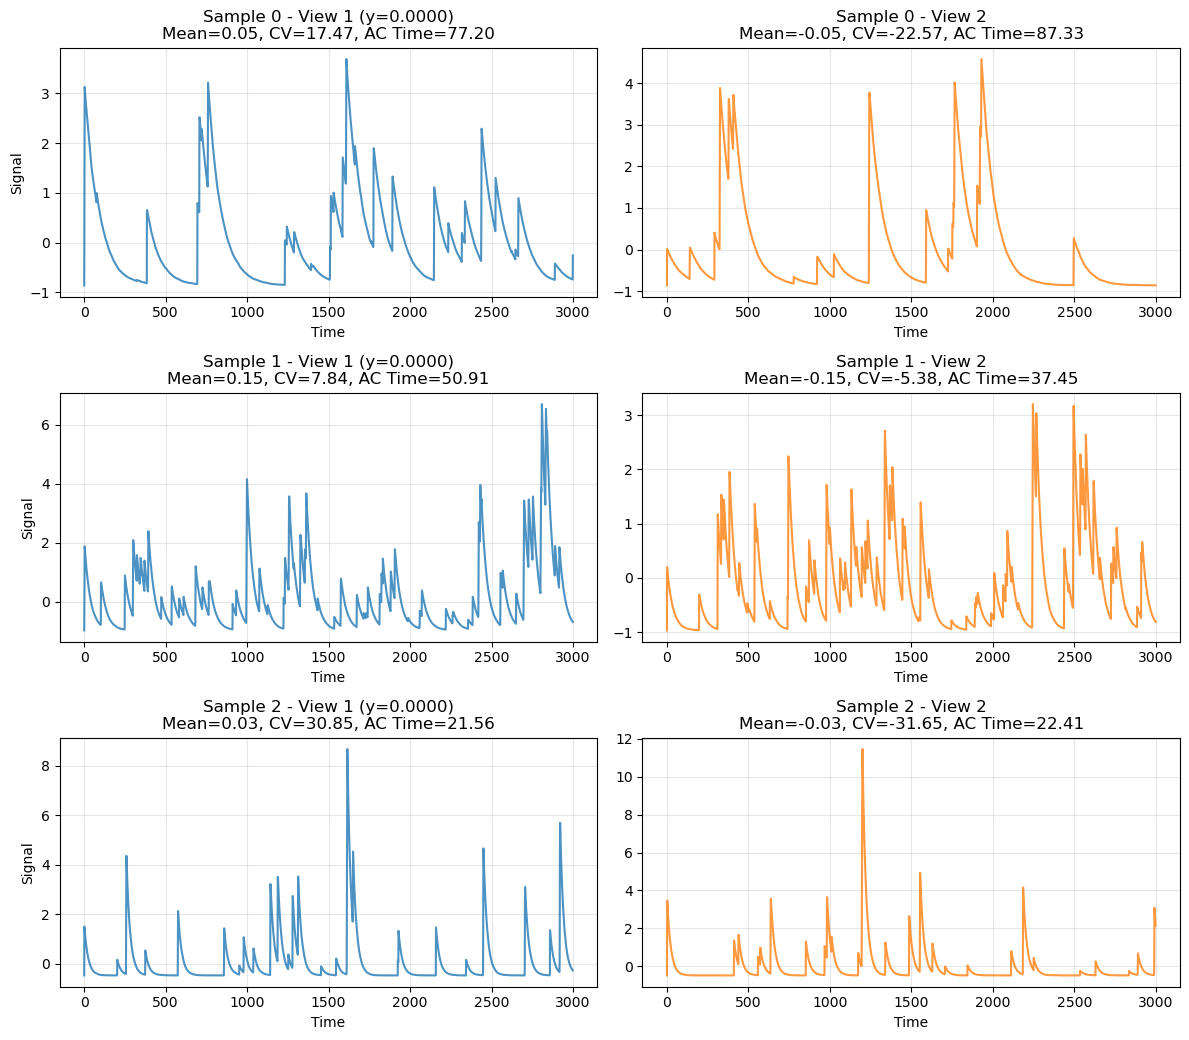

--- Validation Loader (SSL Pairs) ---
Shapes :: X1: torch.Size([64, 3000, 1]), X2: torch.Size([64, 3000, 1]), y: torch.Size([64, 1])


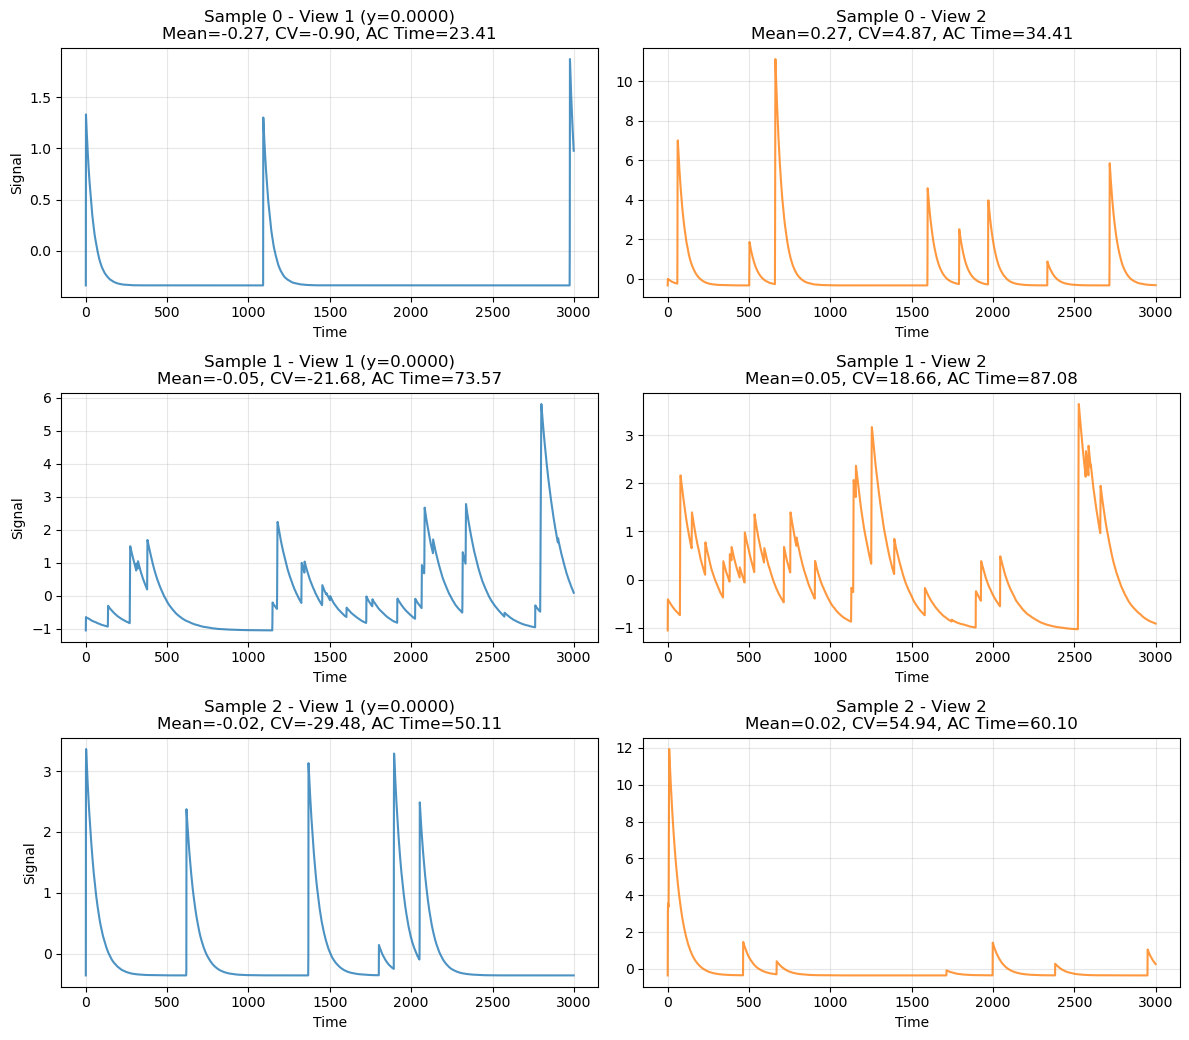

--- Test Loader (SSL Pairs) ---
Shapes :: X1: torch.Size([64, 3000, 1]), X2: torch.Size([64, 3000, 1]), y: torch.Size([64, 1])


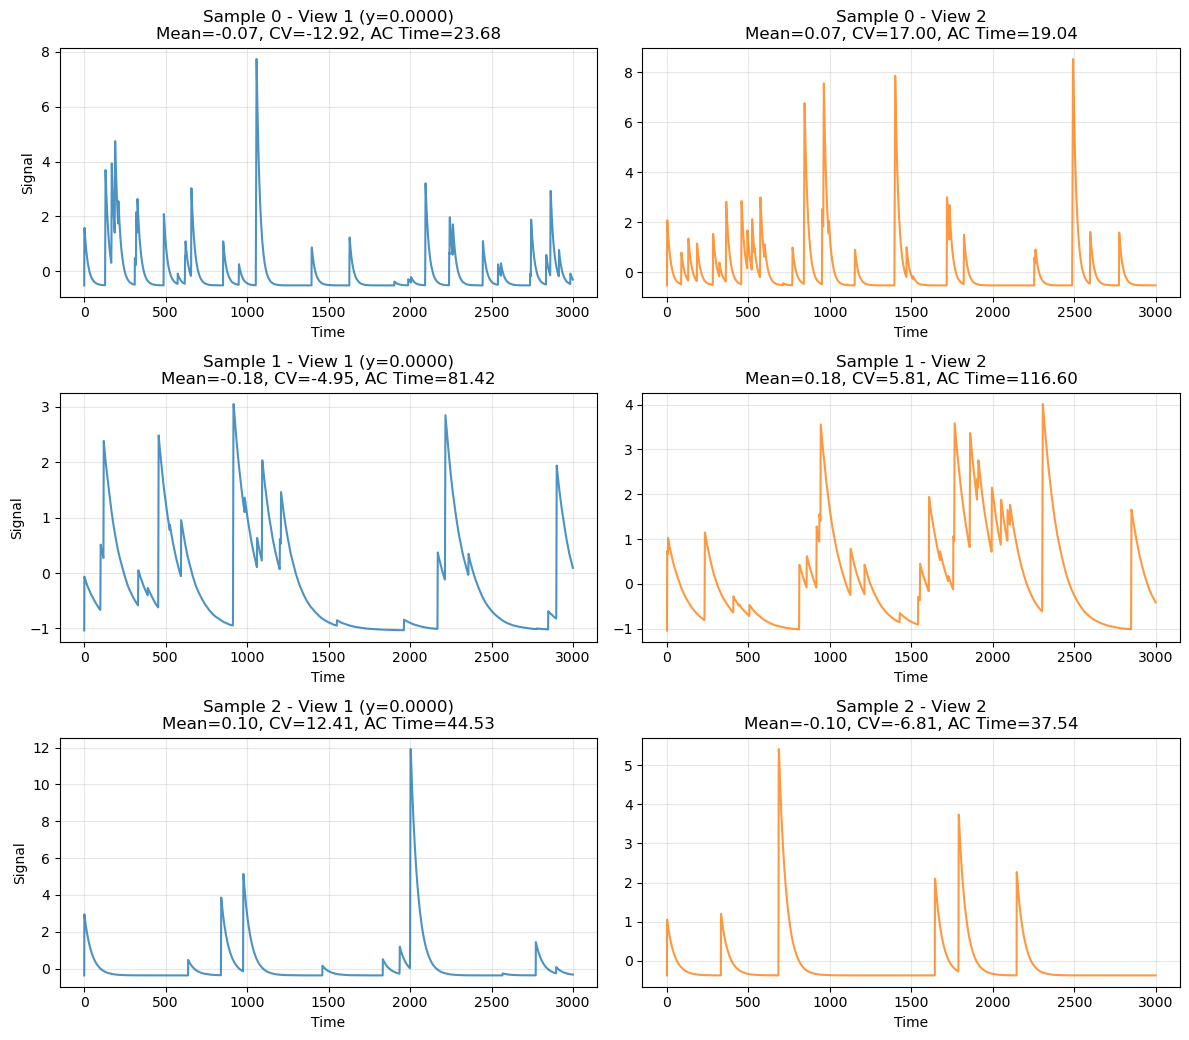

In [ ]:
# Visualize samples
visualize_loader_samples(train_loader, "Train Loader")
if 'val_loader' in locals(): visualize_loader_samples(val_loader, "Validation Loader")
if 'test_loader' in locals(): visualize_loader_samples(test_loader, "Test Loader")

```
normalisation: 'batch-wise'
```

In [13]:
# === Dataloader hyperparams & data prep ===
batch_size = 64
num_traj=1 # number of trajectories per view
sample_len=None
log_scale = False 
normalisation = 'batch-wise'

train_loader, val_loader, test_loader = ssl_data_prep(
    # TRAJ_NPZ_PATH,
    TRAJ_PATH,
    batch_size=batch_size,
    sample_len=sample_len,
    log_scale=log_scale,
    normalisation=normalisation,
    num_traj=num_traj,
)
# === Dataloader hyperparams & data prep ===
X1_b, X2_b, y_b = next(iter(train_loader))
print(X1_b.shape, X2_b.shape, y_b.shape) # (B, T, 1) (B, T, 1) (B, 1)

torch.Size([64, 3000, 1]) torch.Size([64, 3000, 1]) torch.Size([64, 1])


--- Train Loader (SSL Pairs) ---
Shapes :: X1: torch.Size([64, 3000, 1]), X2: torch.Size([64, 3000, 1]), y: torch.Size([64, 1])


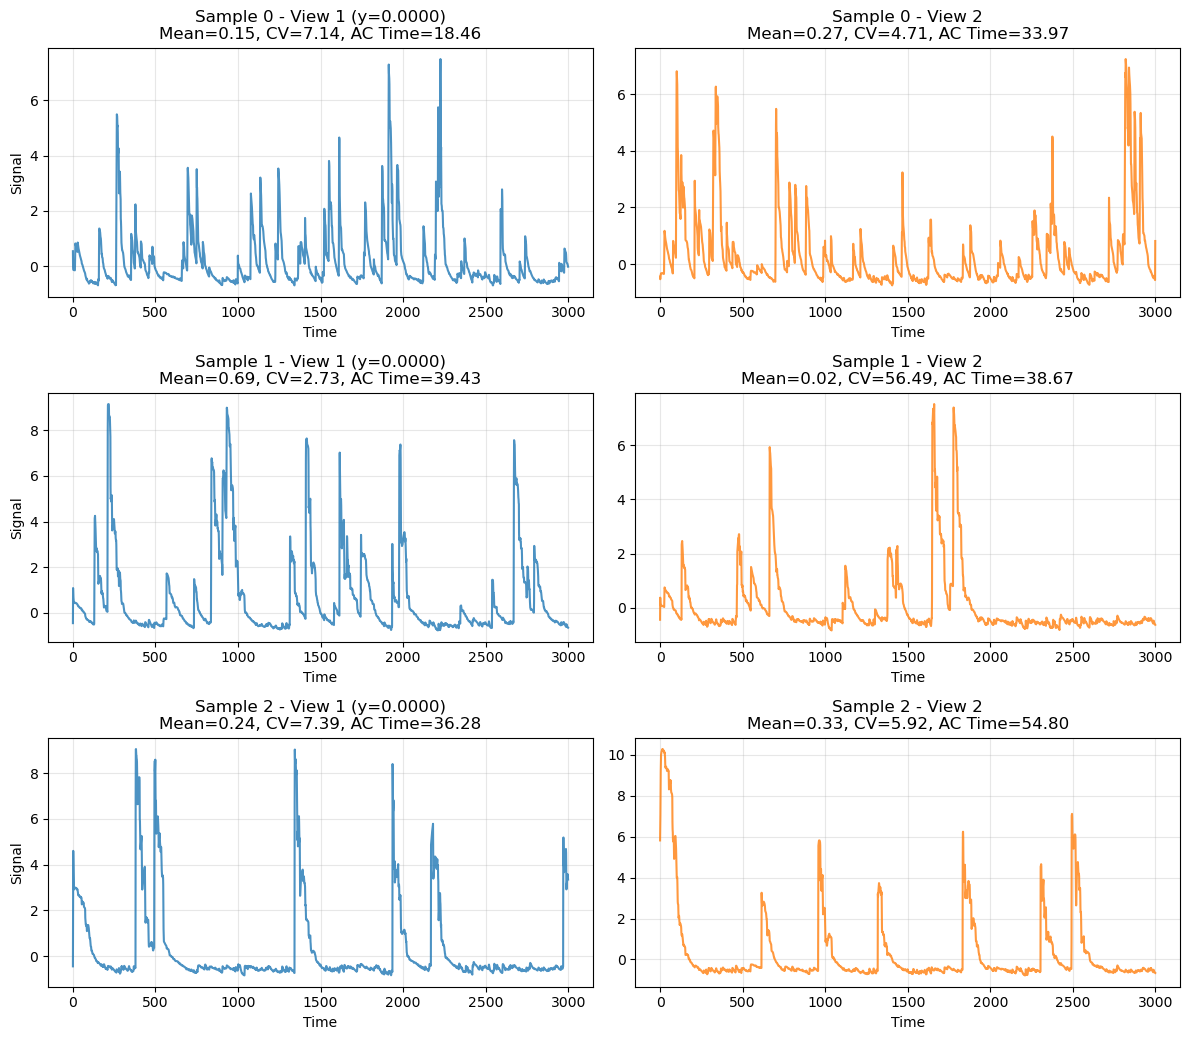

--- Validation Loader (SSL Pairs) ---
Shapes :: X1: torch.Size([64, 3000, 1]), X2: torch.Size([64, 3000, 1]), y: torch.Size([64, 1])


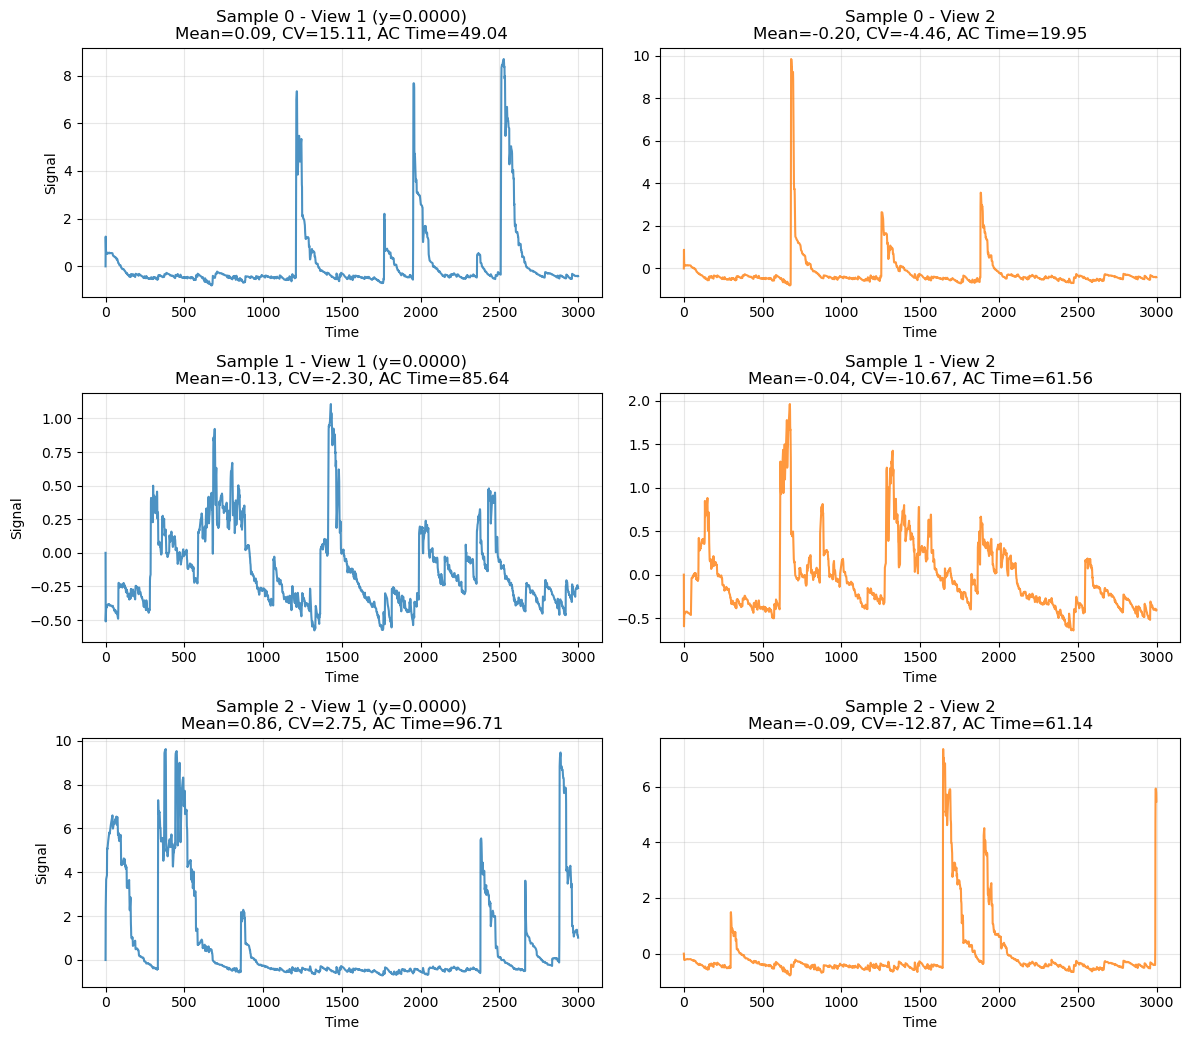

--- Test Loader (SSL Pairs) ---
Shapes :: X1: torch.Size([64, 3000, 1]), X2: torch.Size([64, 3000, 1]), y: torch.Size([64, 1])


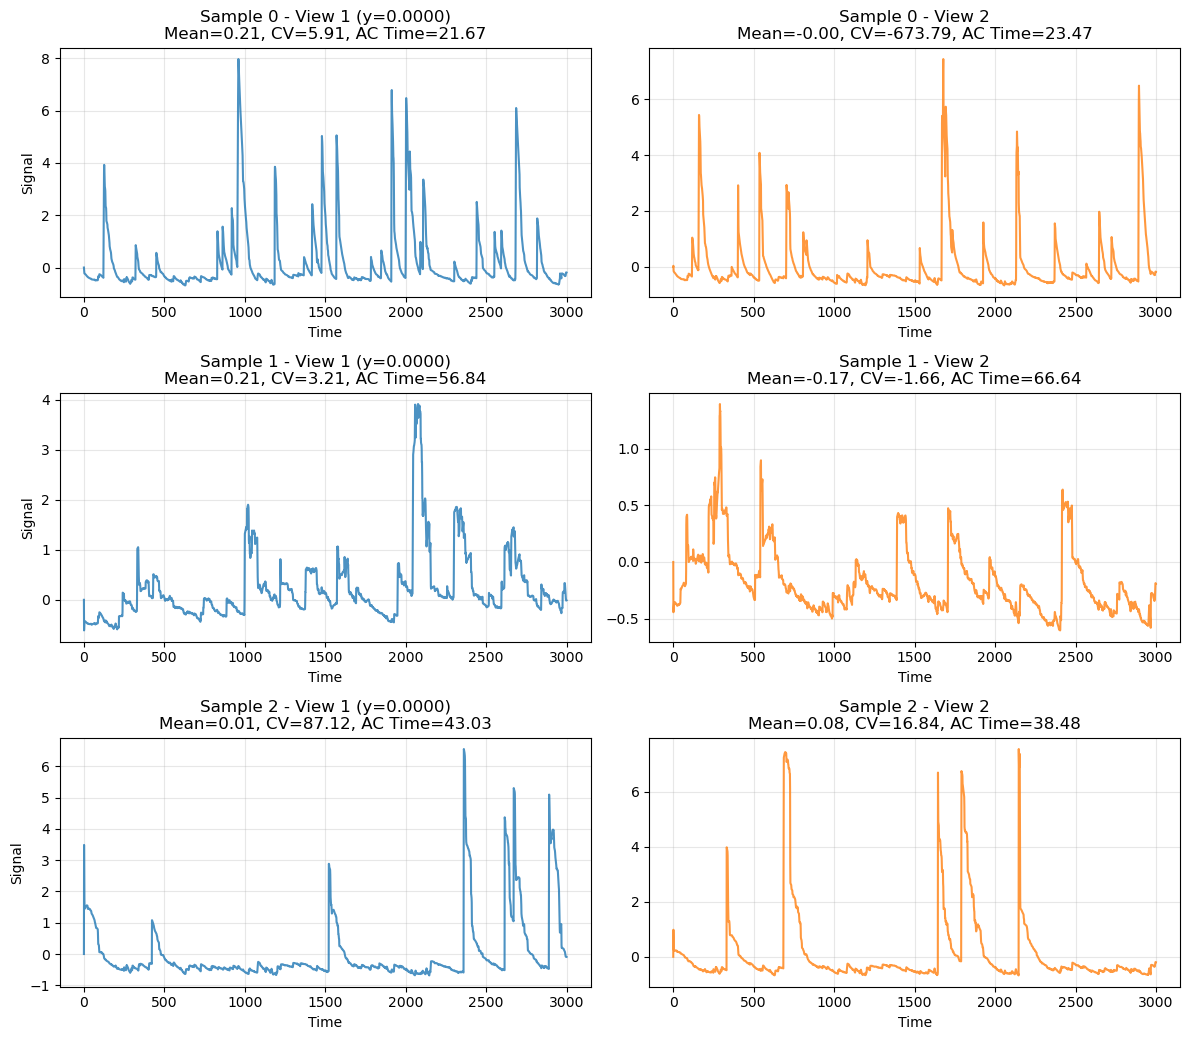

In [15]:
# Visualize samples
visualize_loader_samples(train_loader, "Train Loader")
if 'val_loader' in locals(): visualize_loader_samples(val_loader, "Validation Loader")
if 'test_loader' in locals(): visualize_loader_samples(test_loader, "Test Loader")

---

In [7]:
X1_b, X2_b, y_b = next(iter(train_loader))
print(X1_b.shape, X2_b.shape, y_b.shape) # (B, T, 1) (B, T, 1) (B, 1)
# === Model hyperparams ===
input_size = X1_b.shape[2] 
num_classes = 2
d_model=16
nhead=4
num_layers=2
dropout=0.01
use_conv1d=False 

model = SSL_Transformer(
    input_size=input_size,   
    d_model=d_model,
    nhead=nhead,
    num_layers=num_layers,
    dropout=dropout,
    use_conv1d=use_conv1d,
)
# === Model hyperparams ===

# === Training hyperparams ===
epochs = 50
patience = 50 // 3 # SSL may benefit from high patience
lr = 1e-2 
optimizer = optim.Adam(model.parameters(), lr=lr)

# Cosine Annealing LR Scheduler (good default for SSL)
# scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
# scheduler = None
# 1. simple scheduler choice
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience= patience // 3, factor=0.5) 

# 2. cosine scheduler with warmup, most commonly used for transformer
warmup_steps = int(0.1 * epochs)   # 10% warmup (good default)
from transformers import get_cosine_schedule_with_warmup
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=epochs,
) 

nce_temp = 0.2
loss_fn = InfoNCE(negative_mode='unpaired', temperature=nce_temp)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
grad_clip = None

from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_path = f'IY022_simCLR_b{batch_size}_lr{lr}_L{num_layers}_H{nhead}_D{d_model}_{timestamp}_model.pth'
save_path = model_path
verbose = True

model.to(device)
# === Training hyperparams ===

torch.Size([64, 3000, 1]) torch.Size([64, 3000, 1]) torch.Size([64, 1])


/home/ianyang/micromamba/envs/stochastic_sim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SSL_Transformer(
  (backbone): TransformerClassifier(
    (input_proj): Linear(in_features=1, out_features=16, bias=True)
    (pe): PositionalEncoding()
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=16, out_features=16, bias=True)
          )
          (linear1): Linear(in_features=16, out_features=64, bias=True)
          (dropout): Dropout(p=0.01, inplace=False)
          (linear2): Linear(in_features=64, out_features=16, bias=True)
          (norm1): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.01, inplace=False)
          (dropout2): Dropout(p=0.01, inplace=False)
        )
      )
    )
    (dropout): Dropout(p=0.01, inplace=False)
    (head): Linear(in_features=16, out_features=2, bias=True)
  )
  (

In [8]:
trained_model_paths = ['IY022_simCLR_b64_lr0.01_L2_H4_D16_20260303_170229_model.pth', # global_norm (sample_len = 500)
'IY022_simCLR_b64_lr0.01_L2_H4_D16_20260308_125632_model.pth', # global_norm (sample_len = None)
'IY022_simCLR_b64_lr0.01_L2_H4_D16_20260308_132219_model.pth', # joint_norm (sample_len = None)
'../EXP-26-IY017/IY017_simCLR_b64_lr0.01_L2_H4_D16_20260215_163742_model.pth',  # instance_norm (sample_len = None)
                       ]

In [9]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from tqdm import tqdm

# Import your local modules
from dataloaders.baseline import baseline_data_prep
from models.ssl_transformer import SSL_Transformer

# ==============================================================================
# CONFIGURATION
# ==============================================================================
# Update these paths to match your system
DATA_BASE_DIR = Path("/home/ianyang/stochastic_simulations/experiments/EXP-26-IY020")
# MODEL_CHECKPOINT_PATH = trained_model_paths # change this to load different trained models 

# Model Hyperparameters (MUST MATCH TRAINING)
INPUT_SIZE = input_size
D_MODEL = d_model
NHEAD = nhead
NUM_LAYERS = num_layers
DROPOUT = dropout
USE_CONV1D = use_conv1d
DEVICE = device
# ==============================================================================
# HELPER FUNCTIONS
# ==============================================================================

def load_trained_model(checkpoint_path, device):
    """Instantiates the model and loads weights."""
    print(f"Loading model from {checkpoint_path}...")
    model = SSL_Transformer(
        input_size=INPUT_SIZE,
        d_model=D_MODEL,
        nhead=NHEAD,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        use_conv1d=USE_CONV1D
    )
    
    # Load weights
    try:
        state_dict = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(state_dict)
    except Exception as e:
        print(f"Error loading state dict: {e}")
        print("Tip: If keys don't match, check if you trained with a wrapper or different architecture.")
        raise e
        
    model.to(device)
    model.eval()
    return model

def extract_ssl_features(model, loader, device):
    """
    Extracts features for pairs (x1, x2) using the frozen SSL encoder.
    Feature = |Embed(x1) - Embed(x2)|
    """
    features_list = []
    labels_list = []
    
    with torch.no_grad():
        for batch in tqdm(loader, desc="Extracting SSL Features", leave=False):
            # Baseline loader returns X of shape (Batch, Time, 2) and y (Batch, 1)
            X_batch, y_batch = batch
            X_batch = X_batch.to(device)
            
            # Split the pair into two views
            # X shape is (B, T, 2). Unsqueeze to (B, T, 1) for the model
            x1 = X_batch[:, :, 0].unsqueeze(-1)
            x2 = X_batch[:, :, 1].unsqueeze(-1)
            
            # Get Embeddings
            # Check if model has .encode() (preferred) or use backbone manually
            if hasattr(model, 'encode'):
                z1 = model.encode(x1)
                z2 = model.encode(x2)
            else:
                # Fallback: Forward pass backbone + Mean Pool
                z1 = model.backbone(x1).mean(dim=1)
                z2 = model.backbone(x2).mean(dim=1)
            
                
            # Compute Interaction Feature: Absolute Difference
            # This turns the verification task into a classification task for SVM
            feat = torch.abs(z1 - z2)
            
            # Ensure 2D shape (Batch, Dim)
            feat_np = feat.cpu().numpy()
            
            # Get feature from the
            # z = model.encode(X_batch)
            # feat_np = z.cpu().numpy()
            
            if feat_np.ndim == 1:
                feat_np = feat_np.reshape(-1, 1)
                
            features_list.append(feat_np)
            labels_list.append(y_batch.cpu().numpy())
            
    return np.concatenate(features_list, axis=0), np.concatenate(labels_list, axis=0)

def train_and_evaluate_svm(train_loader, test_loader, model, device, task_name="Task"):
    """
    Pipeline: Extract Features -> Scale -> Train SVM -> Evaluate
    """
    print(f"\n=== Processing {task_name} ===")
    
    # 1. Extract
    print(f"   [1/4] Extracting Train Features...")
    X_train, y_train = extract_ssl_features(model, train_loader, device)
    
    print(f"   [2/4] Extracting Test Features...")
    X_test, y_test = extract_ssl_features(model, test_loader, device)
    
    # 2. Scale
    print(f"   [3/4] Scaling Data...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # 3. Train SVM
    print(f"   [4/4] Training SVM & Evaluating...")
    clf = SVC(kernel='rbf', C=1.0)
    clf.fit(X_train_scaled, y_train.ravel())
    
    # 4. Result
    y_pred = clf.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"   >> {task_name} Accuracy: {acc:.2%}")
    return acc

def make_loaders(data_root: Path, results_csv: str):
    """
    Helper to create loaders for a specific dataset folder.
    Replicates the logic from IY016.
    """
    results_path = data_root / results_csv
    if not results_path.exists():
        print(f"Warning: Could not find {results_path}, skipping...")
        return None, None, None

    df_params = pd.read_csv(results_path) 
    # filter out only successful simulations with no error_message, and mean_rel_error_pct < 10, cv_rel_error_pct  < 10, & t_ac_rel_error_pct < 10
    df_params = df_params[(df_params['success'] == True) & 
                        (df_params['error_message'].isna()) &
                        (df_params['mean_rel_error_pct'] < 10) & 
                        (df_params['cv_rel_error_pct'] < 10) & 
                        (df_params['t_ac_rel_error_pct'] < 10)]
    # Construct .npz paths
    traj_paths = [data_root / fname for fname in df_params['trajectory_filename'].values]
    traj_npz_paths = [p.with_suffix('.npz') for p in traj_paths]

    # Use the fixed baseline_data_prep with stack_axis=1
    train_l, val_l, test_l = baseline_data_prep(
        traj_npz_paths,
        batch_size=batch_size,
        num_groups_train=3000, # Same as IY016
        num_groups_test=600,
        num_traj=2,
        pos_ratio=0.5,
        sample_len=500, # Use the length your SSL model expects!
        stack_axis=1,   # Critical for separating channels later
        verbose=False
    )
    return train_l, val_l, test_l

# ==============================================================================
# MAIN EXECUTION
# ==============================================================================

experiments = [
    {
        "name": "Baseline",
        "folder": "data", 
        "csv": "IY020_simulation_parameters_sobol.csv"
    },
    {
        "name": "CV Variation",
        "folder": "data_cv_variation",
        "csv": "IY020_simulation_cv_parameters_sobol.csv"
    },
    {
        "name": "Mu Variation",
        "folder": "data_mu_variation",
        "csv": "IY020_simulation_mu_parameters_sobol.csv"
    },
    {
        "name": "T_ac Variation",
        "folder": "data_t_ac_variation",
        "csv": "IY020_simulation_t_ac_parameters_sobol.csv"
    }
]

# Collect results across all models: {model_label: {task_name: accuracy}}
all_results = {}

for MODEL_CHECKPOINT_PATH in trained_model_paths:
    model_label = Path(MODEL_CHECKPOINT_PATH).stem

    # 1. Load Model
    ssl_model = load_trained_model(MODEL_CHECKPOINT_PATH, DEVICE)

    results = {}

    # 2. Run Loop over experiments
    for exp in experiments:
        data_path = DATA_BASE_DIR / exp["folder"]
        train_loader, _, test_loader = make_loaders(data_path, exp["csv"])
        if train_loader:
            acc = train_and_evaluate_svm(train_loader, test_loader, ssl_model, DEVICE, task_name=exp["name"])
            results[exp["name"]] = acc

    all_results[model_label] = results

    # Per-model summary
    print("\n" + "="*30)
    print(f"RESULTS: {model_label}")
    print("="*30)
    for name, acc in results.items():
        print(f"{name:.<20} {acc:.2%}")


Loading model from IY022_simCLR_b64_lr0.01_L2_H4_D16_20260303_170229_model.pth...

=== Processing Baseline ===
   [1/4] Extracting Train Features...


   [2/4] Extracting Test Features...


   [3/4] Scaling Data...
   [4/4] Training SVM & Evaluating...
   >> Baseline Accuracy: 62.33%

=== Processing CV Variation ===
   [1/4] Extracting Train Features...


   [2/4] Extracting Test Features...


   [3/4] Scaling Data...
   [4/4] Training SVM & Evaluating...
   >> CV Variation Accuracy: 81.00%

=== Processing Mu Variation ===
   [1/4] Extracting Train Features...


...

   [3/4] Scaling Data...
   [4/4] Training SVM & Evaluating...
   >> CV Variation Accuracy: 86.67%

=== Processing Mu Variation ===
   [1/4] Extracting Train Features...


   [2/4] Extracting Test Features...


   [3/4] Scaling Data...
   [4/4] Training SVM & Evaluating...
   >> Mu Variation Accuracy: 49.33%

=== Processing T_ac Variation ===
   [1/4] Extracting Train Features...


   [2/4] Extracting Test Features...


   [3/4] Scaling Data...
   [4/4] Training SVM & Evaluating...
   >> T_ac Variation Accuracy: 61.67%

RESULTS: IY017_simCLR_b64_lr0.01_L2_H4_D16_20260215_163742_model
Baseline............ 66.00%
CV Variation........ 86.67%
Mu Variation........ 49.33%
T_ac Variation...... 61.67%


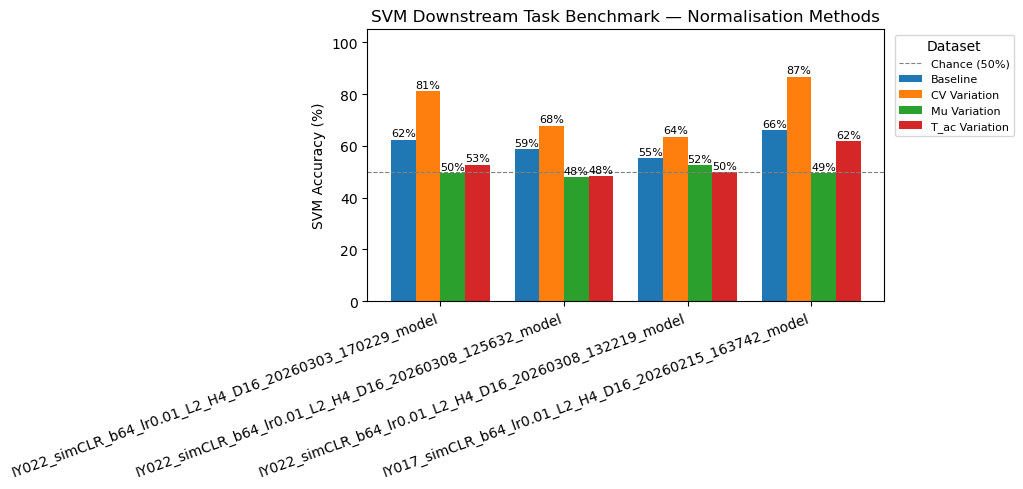

In [10]:
# ==============================================================================
# BENCHMARK PLOT: SVM accuracy across models and tasks
# x-axis = models, bars = datasets/tasks
# ==============================================================================

model_labels = list(all_results.keys())
task_names = [exp["name"] for exp in experiments]

n_models = len(model_labels)
n_tasks = len(task_names)
x = np.arange(n_models)
bar_width = 0.8 / n_tasks  # total group width = 80%

fig, ax = plt.subplots(figsize=(max(10, n_models * 2.5), 5))

for i, task in enumerate(task_names):
    accs = [all_results[m].get(task, np.nan) for m in model_labels]
    offsets = (i - (n_tasks - 1) / 2) * bar_width
    bars = ax.bar(
        x + offsets,
        [a * 100 if not np.isnan(a) else 0 for a in accs],
        width=bar_width,
        label=task,
    )

    # Annotate each bar
    for bar, acc in zip(bars, accs):
        if not np.isnan(acc):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f"{acc:.0%}",
                ha="center",
                va="bottom",
                fontsize=8,
            )

ax.axhline(50, color="grey", linestyle="--", linewidth=0.8, label="Chance (50%)")
ax.set_xticks(x)
ax.set_xticklabels(model_labels, rotation=20, ha="right")
ax.set_ylabel("SVM Accuracy (%)")
ax.set_ylim(0, 105)
ax.set_title("SVM Downstream Task Benchmark — Normalisation Methods")
ax.legend(title="Dataset", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()
